<a href="https://colab.research.google.com/github/Tanishq7361/Radioactive-Decay-and-Projectile-Motion-Visualization/blob/main/Radioactive_Decay_and_Projectile_Motion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Radioactive Decay and Projectile Motion**


## Radioactive Decay:

 Radioactive DecayProblem:Case (a): Species A decays into B, and B decays into A with time constants $\tau_A$ and $\tau_B$. Solve for $N_A(t)$ and $N_B(t)$ with $N_A(0)=100, N_B(0)=0$ for ratios $\tau_A/\tau_B = 0.2, 1.0, 2.2$.Case (b): A decays into B, and B decays into something else (not A). Take $\tau=1$.Analysis: Why does (a) reach a non-zero equilibrium while (b) does not?

---


Mutual Decay: A $\leftrightarrow$ B

### Given
- $N_A(0) = 100$
- $N_B(0) = 0$
- Time constants: $\tau_A, \tau_B$

---


## Mathematical Equations:
Let  
- $N_A(t)$ = number of particles of A  
- $N_B(t)$ = number of particles of B  

Decay constants:
$$
\lambda_A = \frac{1}{\tau_A}, \quad \lambda_B = \frac{1}{\tau_B}
$$

ODEs:
$$
\frac{dN_A}{dt} = -\lambda_A N_A + \lambda_B N_B
$$
$$
\frac{dN_B}{dt} = \lambda_A N_A - \lambda_B N_B
$$

---

### Euler’s Method

For step size $h$:
$$
N_A^{n+1} = N_A^n + h(-\lambda_A N_A^n + \lambda_B N_B^n)
$$
$$
N_B^{n+1} = N_B^n + h(\lambda_A N_A^n - \lambda_B N_B^n)
$$

---

### Dependence on $\tau_A / \tau_B$

- $\tau_A < \tau_B$ $\Rightarrow$ A decays faster $\Rightarrow$ B dominates
- $\tau_A = \tau_B$ $\Rightarrow$ symmetric equilibrium  
- $\tau_A > \tau_B$ $\Rightarrow$ B decays faster $\Rightarrow$ A dominates  

Total particles conserved:
$$
N_A(t) + N_B(t) = 100
$$

---

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def euler(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(len(t)-1):
        y[i+1] = y[i] + (t[i+1]-t[i]) * f(y[i])
    return y


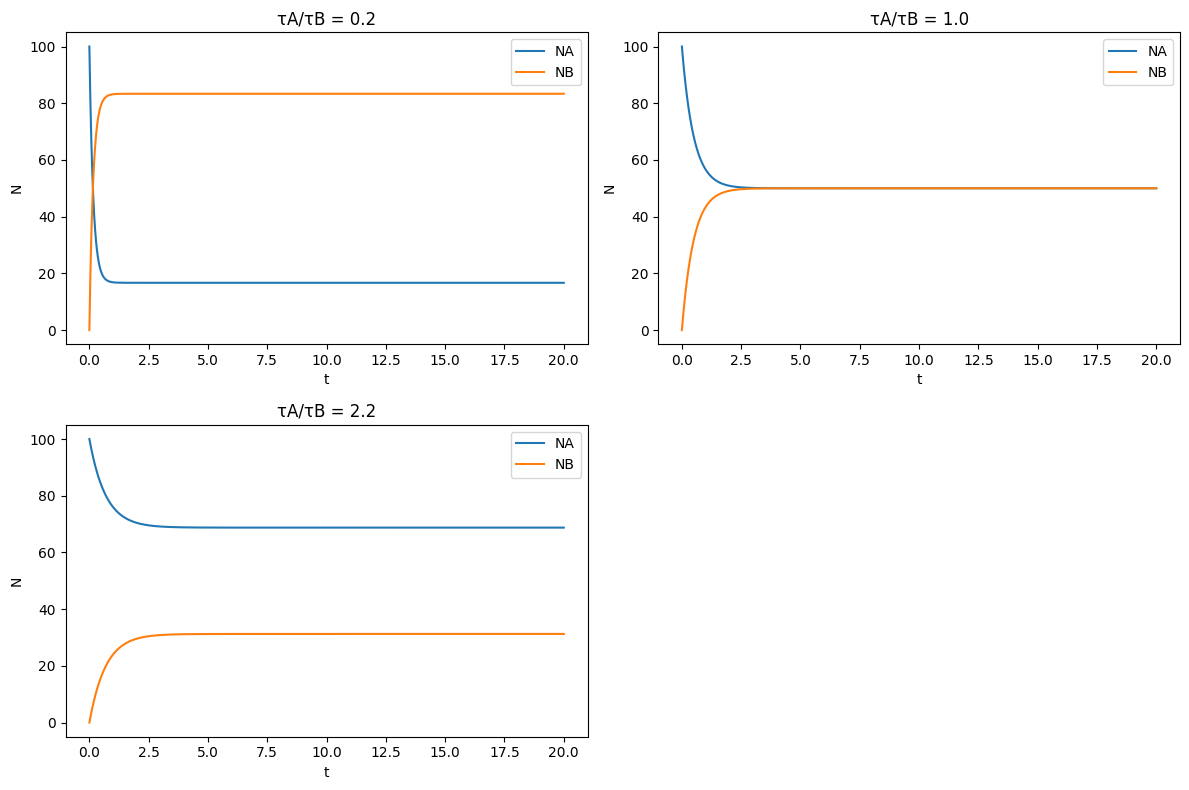

In [2]:
t = np.linspace(0, 20, 2000)

# Ratios tauA / tauB
ratios = [0.2, 1.0, 2.2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, ratio in enumerate(ratios):
    tauB = 1.0
    tauA = ratio * tauB

    lamA = 1 / tauA
    lamB = 1 / tauB

    def f(y):
        NA, NB = y
        return np.array([
            -lamA * NA + lamB * NB,
             lamA * NA - lamB * NB
        ])

    y = euler(f, [100, 0], t)

    axes[i].plot(t, y[:, 0], label='NA')
    axes[i].plot(t, y[:, 1], label='NB')
    axes[i].set_title(f'τA/τB = {ratio}')
    axes[i].set_xlabel('t')
    axes[i].set_ylabel('N')
    axes[i].legend()

# Hide the unused subplot (bottom-right)
axes[3].axis('off')

plt.tight_layout()
plt.show()

### Results

| $\tau_A / \tau_B$ | Behavior |
|------------------|----------|
| $0.2$ | Mostly B |
| $1.0$ | $N_A \approx N_B$ |
| $2.2$ | Mostly A |

---

### Conclusion

Closed system $\Rightarrow$ non-zero equilibrium.
Equilibrium in (a):

In case (a), the system is "closed" regarding A and B. Since A turns into B and B turns back into A, a dynamic balance is reached where the rate of conversion is equal in both directions. The total number of particles ($N_A + N_B$) remains constant.

---

## One-way Decay: $A \rightarrow B \rightarrow$ decay

### Given
- $\tau = 1$

---


### ODEs

$$
\frac{dN_A}{dt} = -N_A
$$
$$
\frac{dN_B}{dt} = N_A - N_B
$$

---

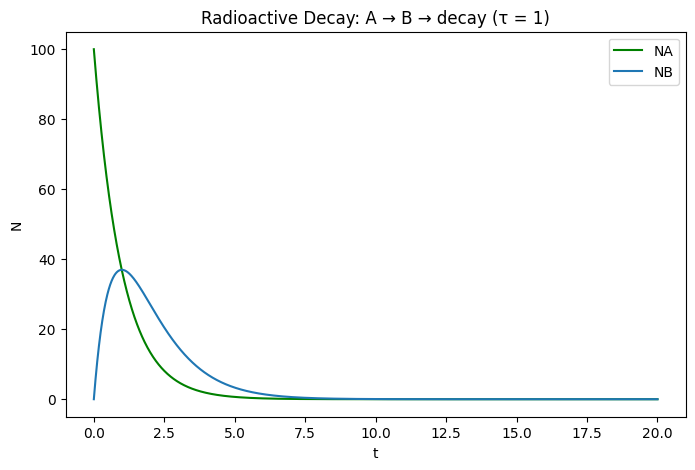

In [3]:
t = np.linspace(0, 20, 2000)

# ODEs for Q1(b): A -> B -> decay, tau = 1
def f(y):
    NA, NB = y
    return np.array([
        -NA,
         NA - NB
    ])

# Initial conditions
y = euler(f, [100, 0], t)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(t, y[:, 0], label='NA',color='green')
plt.plot(t, y[:, 1], label='NB')
plt.xlabel('t')
plt.ylabel('N')
plt.title('Radioactive Decay: A → B → decay (τ = 1)')
plt.legend()
plt.show()


### Asymptotic Behavior

$$
\lim_{t \to \infty} N_A(t) = 0
$$
$$
\lim_{t \to \infty} N_B(t) = 0
$$

---


### Comparison

| Case | Result |
|-----|--------|
| (a) | Closed system, equilibrium $\neq 0$ |
| (b) | Open system, equilibrium $= 0$ |

---

### Conclusion
In case (b), the process is a "one-way". Since B decays into a third species and never returns to A, eventually both  NA  and  NB  will deplete to zero as everything converts to the final stable or subsequent product.

---


## Projectile Motion

### Given

- Initial velocity: $v_0 = 100\,\mathrm{m/s}$
- Acceleration due to gravity: $g = 10\,\mathrm{m/s^2}$
- Air resistance coefficient:
$$
\frac{B^2}{m} = 10^{-5}
$$
- Projection angles: $\theta_1,\theta_2,\theta_3$

---

### Equations of Motion

Let $(x,y)$ be position and $(v_x,v_y)$ be velocity components.

$$
\dot{x} = v_x,\qquad \dot{y} = v_y
$$

With air resistance:
$$
\dot{v_x} = -k\,v\,v_x
$$
$$
\dot{v_y} = -g - k\,v\,v_y
$$

Without air resistance:
$$
\dot{v_x} = 0,\qquad \dot{v_y} = -g
$$

where
$$
v = \sqrt{v_x^2 + v_y^2},\qquad k = 10^{-5}
$$

---

### Euler Method Implementation (Python)

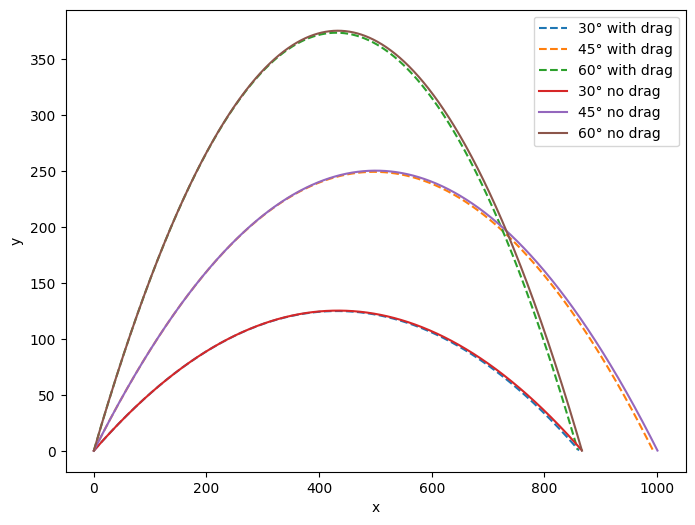

In [4]:
v0, g, k = 100, 10, 1e-5
angles = [30, 45, 60]
dt = 0.01
t = np.arange(0, 20, dt)

plt.figure(figsize=(8,6))

for drag in [True, False]:
    for a in angles:
        theta = np.radians(a)

        def f(y):
            x, y_, vx, vy = y
            v = np.sqrt(vx**2 + vy**2)
            ax = -k*v*vx if drag else 0
            ay = -g - k*v*vy if drag else -g
            return np.array([vx, vy, ax, ay])

        sol = euler(f, [0, 0, v0*np.cos(theta), v0*np.sin(theta)], t)
        mask = sol[:,1] >= 0
        style = '--' if drag else '-'
        plt.plot(sol[mask,0], sol[mask,1], style,
                 label=f'{a}° {"with drag" if drag else "no drag"}')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Observations

- For $B^2 = 0$ (no air resistance), the projectile follows a **parabolic trajectory** as predicted by analytical mechanics.
- When air resistance is included $\left(\frac{B^2}{m} = 10^{-5}\right)$, the trajectory becomes **asymmetric** due to velocity-dependent drag.
- The **maximum height** attained by the projectile is reduced in the presence of air resistance.
- The **horizontal range** with air resistance is always **less** than the range without air resistance.
- For motion without air resistance, the angle of projection giving maximum range is $45^\circ$.
- With air resistance, the angle for maximum range is **less than $45^\circ$**.
- Increasing the angle of projection increases the time of flight, but the range does not increase proportionally when drag is present.

---

## Conclusions

- Projectile motion can be accurately modeled using **Euler’s method** for sufficiently small time steps.
- In the absence of air resistance, numerical results match the **theoretical parabolic path**.
- Air resistance introduces **non-linearity** into the equations of motion through velocity-dependent forces.
- The presence of air resistance significantly affects both the **shape** and **range** of the trajectory.
- Numerical methods are essential for solving equations of motion that do not have simple closed-form solutions.
- Euler’s method provides a simple and effective approach for studying such dynamical systems.